# 03. Content-Based TF-IDF

В этом notebook мы переходим от глобальной popularity-логики к персонализированным рекомендациям по признакам самих объектов.

## Что изучим

- что такое content-based рекомендации;
- как превратить жанры `MovieLens` в TF-IDF признаки;
- как собрать простой user-profile из понравившихся фильмов;
- как рекомендовать unseen фильмы по близости к этому профилю;
- как сравнить content-based модель с popularity baseline.


## Интуиция

Если popularity baseline говорит: "покажем всем самые частые фильмы", то content-based подход говорит: "покажем пользователю фильмы, похожие на те, что ему уже нравились".

Плюсы такого подхода:

- рекомендации становятся персонализированными;
- модель не зависит напрямую от поведения других пользователей;
- легче объяснить, почему объекты похожи.

Ограничение здесь тоже важное: качество такой модели сильно зависит от признаков объектов. В нашем учебном варианте признаки очень простые: только жанры из `movies.csv`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero


In [2]:
from recsys_basics.basic.content_based import (
    ContentBasedRecommender,
    prepare_genre_text_features,
)
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import build_explicit_interactions, get_movielens_data_dir, load_movielens_frames
from recsys_basics.split import assert_no_user_time_leakage, leave_last_one_out_split

DATA_DIR = get_movielens_data_dir()
MIN_RATING = 4.0
TOP_K = 10

frames = load_movielens_frames(DATA_DIR)
interactions_df = build_explicit_interactions(frames.ratings)
movies_df = frames.movies.rename(columns={"movieId": "item_id"}).copy()
movies_features_df = prepare_genre_text_features(movies_df)
positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)

split_result = leave_last_one_out_split(positive_df, min_user_interactions=2)
train_df = split_result.train
test_df = split_result.test
assert_no_user_time_leakage(train_df, test_df)

seen_items_map = build_seen_items_map(train_df)
user_histories = (
    train_df.sort_values(["user_id", "timestamp", "item_id"])
    .groupby("user_id")["item_id"]
    .agg(list)
    .to_dict()
)

print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Users in evaluation: {len(user_histories):,}")


Train rows: 47,971
Test rows: 608
Users in evaluation: 608


## Превращаем жанры в TF-IDF признаки

Мы не используем сложные эмбеддинги или нейросети. Вместо этого берём строку жанров из `movies.csv`, превращаем её в простой текст и строим TF-IDF представление.

Это очень упрощённый вариант content-based модели, но он хорошо подходит для первого знакомства:

- видно, откуда берутся признаки;
- легко показать похожие фильмы;
- можно честно сравнить с popularity baseline.


In [3]:
display(movies_features_df[["item_id", "title", "genres", "genres_text"]].head(10))

genre_token_counts = (
    movies_features_df["genres_text"]
    .str.split()
    .explode()
    .value_counts()
    .rename_axis("genre_token")
    .reset_index(name="movie_count")
)
display(genre_token_counts.head(10))


,item_id,title,genres,genres_text
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy,Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,Comedy Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,Comedy
5,6,Heat (1995),Action|Crime|Thriller,Action Crime Thriller
6,7,Sabrina (1995),Comedy|Romance,Comedy Romance
7,8,Tom and Huck (1995),Adventure|Children,Adventure Children
8,9,Sudden Death (1995),Action,Action
9,10,GoldenEye (1995),Action|Adventure|Thriller,Action Adventure Thriller


,genre_token,movie_count
0,Drama,4361
1,Comedy,3756
2,Thriller,1894
3,Action,1828
4,Romance,1596
5,Adventure,1263
6,Crime,1199
7,Sci-Fi,980
8,Horror,978
9,Fantasy,779


In [4]:
content_model = ContentBasedRecommender().fit(movies_features_df)

tfidf_summary = pd.DataFrame(
    {
        "metric": ["n_movies", "n_tfidf_features"],
        "value": [len(movies_features_df), len(content_model.feature_names_)],
    }
)
display(tfidf_summary)
display(pd.Series(content_model.feature_names_[:20], name="sample_tfidf_features").to_frame())


,metric,value
0,n_movies,9742
1,n_tfidf_features,175


,sample_tfidf_features
0,action
1,action adventure
2,action animation
3,action children
4,action comedy
5,action crime
6,action documentary
7,action drama
8,action fantasy
9,action horror


## Интуитивная проверка: похожие фильмы по жанрам

Прежде чем рекомендовать пользователю, полезно убедиться, что item-features хотя бы примерно работают. Для этого посмотрим, какие фильмы модель считает похожими на один опорный фильм.


In [5]:
anchor_title = "Toy Story (1995)"
anchor_item_id = int(movies_features_df.loc[movies_features_df["title"] == anchor_title, "item_id"].iloc[0])

anchor_profile = content_model.get_item_profile(anchor_item_id).head(10).rename("tfidf_weight").to_frame()
similar_items_df = content_model.get_similar_items(anchor_item_id, k=10)

print(f"Anchor movie: {anchor_title} | item_id={anchor_item_id}")
display(anchor_profile)
display(similar_items_df)


Anchor movie: Toy Story (1995) | item_id=1


,tfidf_weight
comedy fantasy,0.4051
adventure animation,0.4009
animation children,0.3837
children comedy,0.3682
animation,0.3234
children,0.3162
fantasy,0.3025
adventure,0.2611
comedy,0.1676


,item_id,similarity,title,genres_text
0,45074,1.0000,"Wild, The (2006)",Adventure Animation Children Comedy Fantasy
1,53121,1.0000,Shrek the Third (2007),Adventure Animation Children Comedy Fantasy
2,3114,1.0000,Toy Story 2 (1999),Adventure Animation Children Comedy Fantasy
3,136016,1.0000,The Good Dinosaur (2015),Adventure Animation Children Comedy Fantasy
4,3754,1.0000,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure Animation Children Comedy Fantasy
5,2294,1.0000,Antz (1998),Adventure Animation Children Comedy Fantasy
6,166461,1.0000,Moana (2016),Adventure Animation Children Comedy Fantasy
7,4886,1.0000,"Monsters, Inc. (2001)",Adventure Animation Children Comedy Fantasy
8,91355,1.0000,Asterix and the Vikings (Astérix et les Viking...,Adventure Animation Children Comedy Fantasy
9,103755,1.0000,Turbo (2013),Adventure Animation Children Comedy Fantasy


## Строим персональные рекомендации

User-profile здесь строится просто: берём фильмы, которые пользователь положительно оценил в `train`, и усредняем их TF-IDF векторы.

Дальше:

- считаем близость между этим профилем и всеми фильмами каталога;
- исключаем already seen items из `train`;
- берём top-K unseen фильмов.


In [6]:
content_recommendations_df = content_model.recommend_many(
    user_histories=user_histories,
    seen_items_map=seen_items_map,
    k=TOP_K,
)

popularity_model = PopularityRecommender().fit(train_df)
popularity_recommendations_df = popularity_model.recommend_many(
    user_ids=sorted(user_histories.keys()),
    seen_items_map=seen_items_map,
    k=TOP_K,
)

all_user_ids = sorted(list(user_histories.keys()))
user_hit_flags = []
for user_id in all_user_ids:
    test_item_id = int(test_df.loc[test_df["user_id"] == user_id, "item_id"].iloc[0])
    content_recs = content_model.recommend(
        history_item_ids=user_histories[int(user_id)],
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    popularity_recs = popularity_model.recommend(
        user_id=int(user_id),
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    user_hit_flags.append(
        {
            "user_id": int(user_id),
            "test_item_id": test_item_id,
            "content_hit_at_10": test_item_id in content_recs,
            "popularity_hit_at_10": test_item_id in popularity_recs,
        }
    )

user_hit_flags_df = pd.DataFrame(user_hit_flags)
sample_hit_users = user_hit_flags_df[user_hit_flags_df["content_hit_at_10"]]["user_id"].head(2).tolist()
sample_miss_users = user_hit_flags_df[~user_hit_flags_df["content_hit_at_10"]]["user_id"].head(3).tolist()
sample_user_ids = sample_hit_users + sample_miss_users

sample_rows = []
for user_id in sample_user_ids:
    test_item_id = int(test_df.loc[test_df["user_id"] == user_id, "item_id"].iloc[0])
    content_recs = content_model.recommend(
        history_item_ids=user_histories[int(user_id)],
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    popularity_recs = popularity_model.recommend(
        user_id=int(user_id),
        seen_items=seen_items_map.get(int(user_id), set()),
        k=TOP_K,
    )
    sample_rows.append(
        {
            "user_id": int(user_id),
            "history_length": len(user_histories[int(user_id)]),
            "test_item_id": test_item_id,
            "content_hit_at_10": test_item_id in content_recs,
            "popularity_hit_at_10": test_item_id in popularity_recs,
            "content_recommendations": content_recs,
        }
    )

sample_recommendations_df = pd.DataFrame(sample_rows)
display(sample_recommendations_df)


,user_id,history_length,test_item_id,content_hit_at_10,popularity_hit_at_10,content_recommendations
0,32,59,224,True,False,"[54780, 6344, 6370, 232, 32009, 5503, 4584, 34..."
1,349,20,145,True,False,"[20, 145, 1432, 5628, 5027, 7007, 3893, 144606..."
2,1,199,2492,False,False,"[5657, 6990, 26340, 108932, 51939, 4818, 2890,..."
3,2,18,80489,False,False,"[1432, 5628, 7007, 145, 20, 5027, 4085, 8370, ..."
4,3,15,3024,False,False,"[86835, 1037, 31424, 95796, 4552, 8810, 91660,..."


In [7]:
def hit_rate_at_k(test_interactions: pd.DataFrame, recommendations: pd.DataFrame, k: int) -> float:
    top_k = recommendations[recommendations["rank"] <= k]
    merged = test_interactions[["user_id", "item_id"]].merge(
        top_k,
        on=["user_id", "item_id"],
        how="left",
    )
    return float(merged["rank"].notna().mean())


def catalog_coverage(recommendations: pd.DataFrame, catalog_item_ids: pd.Series) -> float:
    if len(catalog_item_ids) == 0:
        return 0.0
    return float(recommendations["item_id"].nunique() / catalog_item_ids.nunique())


content_hit_rate_10 = hit_rate_at_k(test_df, content_recommendations_df, k=TOP_K)
popularity_hit_rate_10 = hit_rate_at_k(test_df, popularity_recommendations_df, k=TOP_K)
content_coverage = catalog_coverage(content_recommendations_df, train_df["item_id"])
popularity_coverage = catalog_coverage(popularity_recommendations_df, train_df["item_id"])

comparison_df = pd.DataFrame(
    {
        "model": ["popularity_baseline", "content_based_tfidf"],
        "HitRate@10": [f"{popularity_hit_rate_10:.2%}", f"{content_hit_rate_10:.2%}"],
        "catalog_coverage": [f"{popularity_coverage:.2%}", f"{content_coverage:.2%}"],
        "unique_recommended_items": [
            popularity_recommendations_df["item_id"].nunique(),
            content_recommendations_df["item_id"].nunique(),
        ],
    }
)
display(comparison_df)


,model,HitRate@10,catalog_coverage,unique_recommended_items
0,popularity_baseline,3.95%,0.97%,61
1,content_based_tfidf,0.49%,37.65%,2358


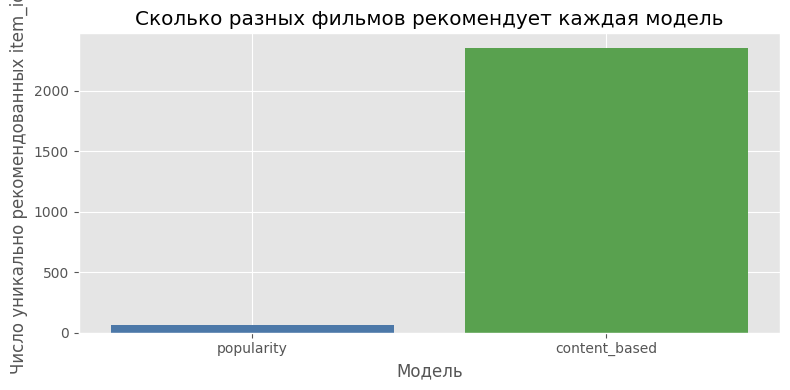

In [8]:
coverage_plot_df = pd.DataFrame(
    {
        "model": ["popularity", "content_based"],
        "unique_recommended_items": [
            popularity_recommendations_df["item_id"].nunique(),
            content_recommendations_df["item_id"].nunique(),
        ],
    }
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(coverage_plot_df["model"], coverage_plot_df["unique_recommended_items"], color=["#4C78A8", "#59A14F"])
ax.set_title("Сколько разных фильмов рекомендует каждая модель")
ax.set_xlabel("Модель")
ax.set_ylabel("Число уникально рекомендованных item_id")
plt.tight_layout()
plt.show()


## Интерпретация результата

В этом запуске `content-based` модель проиграла `popularity baseline` по `HitRate@10`: `0.49%` против `3.95%`.

Это значит, что одних жанров оказалось недостаточно, чтобы часто угадывать скрытый test-фильм пользователя.

Но одновременно `content-based` модель резко увеличила покрытие каталога: `37.65%` против `0.97%`, а число уникально рекомендованных фильмов выросло с `61` до `2358`.

Практический вывод здесь такой:

- `popularity baseline` лучше ловит очень популярные фильмы;
- `content-based` уже даёт персонализацию и выходит за пределы узкого head-набора;
- текущие item-features слишком слабые, чтобы эта персонализация сразу дала лучший `HitRate@10`.

Для `MovieLens` с признаками только из `genres` это ожидаемый результат. Модель полезна как первый пример персонализации, но ещё не как сильный quality baseline.


## Ограничения метода

У этого учебного content-based подхода есть очевидные ограничения:

- признаки объекта очень простые: только жанры;
- фильмы с одинаковыми жанрами могут получать почти одинаковые представления;
- модель плохо помогает там, где важны скрытые предпочтения, а не явные metadata;
- cold-start для новых пользователей не решается без их истории;
- качество рекомендаций зависит от полноты и качества описаний объектов.


## Что получилось

После этого notebook должно быть понятно:

- как построить простой content-based recommender на TF-IDF;
- как использовать историю liked items для персонализации;
- чем такой подход отличается от popularity baseline;
- почему качество content-based модели упирается в качество item-features;
- зачем baseline всё равно нужен даже после перехода к персонализированным моделям.

## Что дальше

Следующий шаг: [04_item_item_cf.ipynb](/Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/notebooks/basic/04_item_item_cf.ipynb). Там мы уйдём от признаков самих фильмов и начнём использовать совместное поведение пользователей.
